# Чувствительность к параметрам
Меняется один параметр за раз. По 20 повторов, горизонт 80.

Row,parameter,value,mean_peak,mean_time_peak,mean_R_T,mean_I_T
,String,Float64,Float64,Float64,Float64,Float64
1,beta,0.03,33.4,20.6438,249.65,2.95
2,beta,0.05,174.4,18.3399,800.3,0.1
3,beta,0.07,291.55,11.7713,923.6,0.0
4,contact,6.0,26.45,20.1968,184.6,2.3
5,contact,10.0,174.4,18.3399,800.3,0.1
6,contact,14.0,295.05,12.0127,927.75,0.0
7,recovery,0.15,348.6,16.6245,958.1,0.15
8,recovery,0.25,174.4,18.3399,800.3,0.1
9,recovery,0.35,70.35,22.8771,520.35,2.1


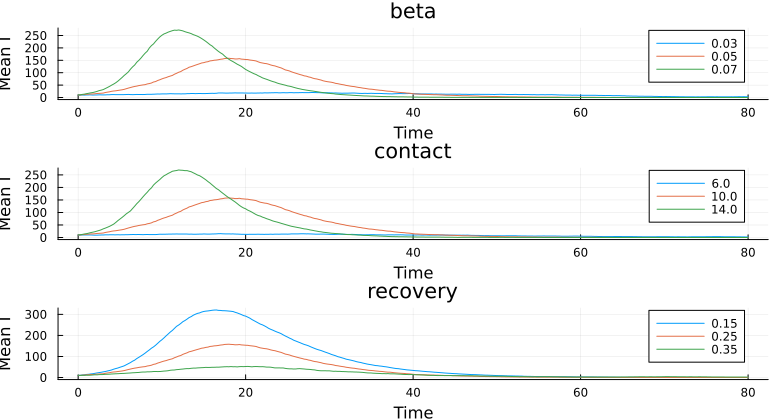

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


rows = NamedTuple[]
panels = []
for (variable,values) in [(:beta,[0.03,0.05,0.07]),
        (:contact,[6.0,10.0,14.0]),(:recovery,[0.15,0.25,0.35])]
    p = plot(xlabel="Time",ylabel="Mean I",title=string(variable))
    for value in values
        cfg = Settings(;Dict(variable=>value)...)
        result = ensemble(cfg)
        for row in eachrow(result.metrics)
            push!(rows,(;parameter=string(variable),value,
                NamedTuple(row)...))
        end
        save_table("scan_$(variable)_$(value)",result.path)
        plot!(p,result.path.t,result.path.mean_I,label=string(value))
    end
    push!(panels,p)
end
metrics = DataFrame(rows)
save_table("sensitivity_runs",metrics)
summary = combine(groupby(metrics,[:parameter,:value]),
    :peak=>mean=>:mean_peak,:time_peak=>mean=>:mean_time_peak,
    :R_T=>mean=>:mean_R_T,:I_T=>mean=>:mean_I_T)
save_table("sensitivity_summary",summary)
display(summary)
figure = plot(panels...;layout=(3,1),size=(1050,1100))
savefig(figure,imagefile("sensitivity"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*